In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})
import seaborn as sns

# modelling
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold, cross_val_score,cross_val_predict,KFold
from sklearn.metrics import make_scorer,mean_squared_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.svm import LinearSVR, SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures,MinMaxScaler,StandardScaler

In [2]:
#load_dataset
with open("./zhengqi_train.txt")  as fr:
    data_train=pd.read_table(fr,sep="\t")
with open("./zhengqi_test.txt") as fr_test:
    data_test=pd.read_table(fr_test,sep="\t")

In [3]:
#merge train_set and test_set
data_train["oringin"]="train"
data_test["oringin"]="test"
data_all=pd.concat([data_train,data_test],axis=0,ignore_index=True)

In [4]:
data_all.drop(["V5","V9","V11","V17","V22","V28"],axis=1,inplace=True)

In [5]:
# normalise numeric columns
cols_numeric=list(data_all.columns)
cols_numeric.remove("oringin")
def scale_minmax(col):
    return (col-col.min())/(col.max()-col.min())
scale_cols = [col for col in cols_numeric if col!='target']
data_all[scale_cols] = data_all[scale_cols].apply(scale_minmax,axis=0)

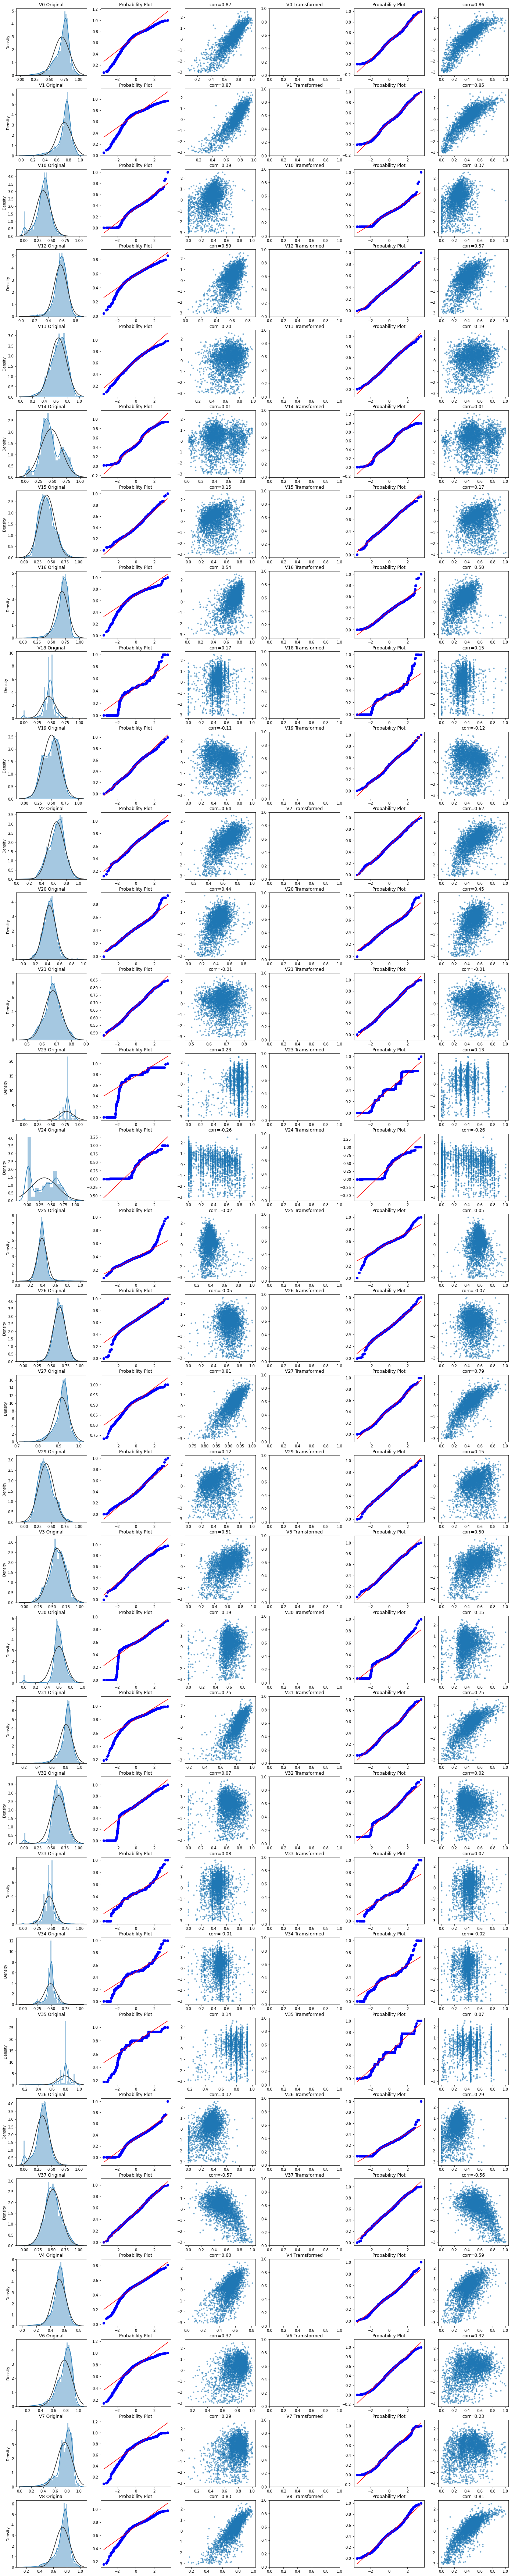

In [6]:
#Check effect of Box-Cox transforms on distributions of continuous variables

fcols = 6
frows = len(cols_numeric)-1
plt.figure(figsize=(4*fcols,4*frows))
i=0

for var in cols_numeric:
    if var!='target':
        dat = data_all[[var, 'target']].dropna()
        
        i+=1
        plt.subplot(frows,fcols,i)
        sns.distplot(dat[var] , fit=stats.norm);

        plt.title(var+' Original')
        plt.xlabel('')
        
        i+=1
        plt.subplot(frows,fcols,i)
        _=stats.probplot(dat[var], plot=plt)
#         plt.title('skew='+'{:.4f}'.format(stats.skew(dat[var])))
        plt.xlabel('')
        plt.ylabel('')
        
        i+=1
        plt.subplot(frows,fcols,i)
        plt.plot(dat[var], dat['target'],'.',alpha=0.5)
        plt.title('corr='+'{:.2f}'.format(np.corrcoef(dat[var], dat['target'])[0][1]))
 
        i+=1
        plt.subplot(frows,fcols,i)
        trans_var, lambda_var = stats.boxcox(dat[var].dropna()+1)
        trans_var = scale_minmax(trans_var)      
#         sns.distplot(trans_var , fit=stats.norm);
        plt.title(var+' Tramsformed')
        plt.xlabel('')
                
        i+=1
        plt.subplot(frows,fcols,i)
        _=stats.probplot(trans_var, plot=plt)
#         plt.title('skew='+'{:.4f}'.format(stats.skew(trans_var)))
        plt.xlabel('')
        plt.ylabel('')
        
        i+=1
        plt.subplot(frows,fcols,i)
        plt.plot(trans_var, dat['target'],'.',alpha=0.5)
        plt.title('corr='+'{:.2f}'.format(np.corrcoef(trans_var,dat['target'])[0][1]))

In [7]:
cols_transform=data_all.columns[0:-2]
for col in cols_transform:   
    # transform column
    data_all.loc[:,col], _ = stats.boxcox(data_all.loc[:,col]+1)

count    2888.000000
mean        0.126353
std         0.983966
min        -3.044000
25%        -0.350250
50%         0.313000
75%         0.793250
max         2.538000
Name: target, dtype: float64


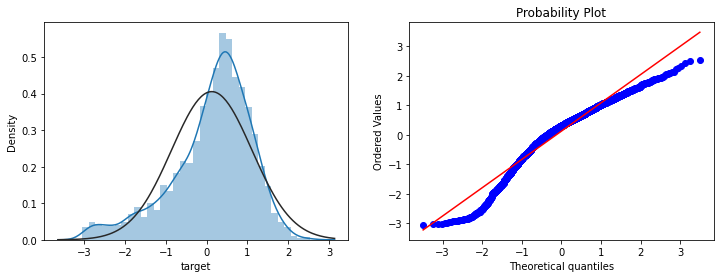

In [8]:
print(data_all.target.describe())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.distplot(data_all.target.dropna() , fit=stats.norm);
plt.subplot(1,2,2)
_=stats.probplot(data_all.target.dropna(), plot=plt)

count    2888.000000
mean        1.129957
std         0.394110
min         0.291057
25%         0.867609
50%         1.135315
75%         1.379382
max         2.798463
Name: target, dtype: float64


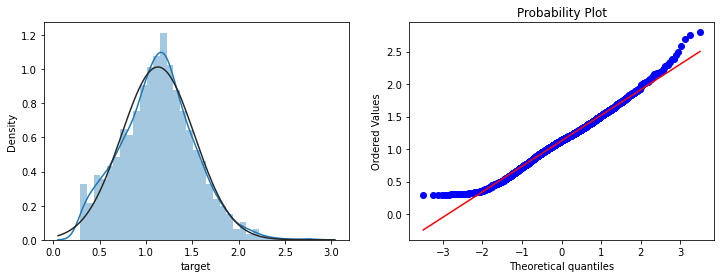

In [9]:
#Log Transform SalePrice to improve normality
sp = data_train.target
data_train.target1 =np.power(1.5,sp)
print(data_train.target1.describe())

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.distplot(data_train.target1.dropna(),fit=stats.norm);
plt.subplot(1,2,2)
_=stats.probplot(data_train.target1.dropna(), plot=plt)

In [10]:
# function to get training samples
def get_training_data():
    # extract training samples
    from sklearn.model_selection import train_test_split
    df_train = data_all[data_all["oringin"]=="train"]
    df_train["label"]=data_train.target1
    # split SalePrice and features
    y = df_train.target
    X = df_train.drop(["oringin","target","label"],axis=1)
    X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.3,random_state=100)
    return X_train,X_valid,y_train,y_valid

# extract test data (without SalePrice)
def get_test_data():
    df_test = data_all[data_all["oringin"]=="test"].reset_index(drop=True)
    return df_test.drop(["oringin","target"],axis=1)

In [11]:
from sklearn.metrics import make_scorer
# metric for evaluation
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    sum_sq = sum(diff**2)    
    n = len(y_pred)   
    
    return np.sqrt(sum_sq/n)
def mse(y_ture,y_pred):
    return mean_squared_error(y_ture,y_pred)

# scorer to be used in sklearn model fitting
rmse_scorer = make_scorer(rmse, greater_is_better=False)
mse_scorer = make_scorer(mse, greater_is_better=False)

In [12]:
# function to detect outliers based on the predictions of a model
def find_outliers(model, X, y, sigma=3):

    # predict y values using model
    try:
        y_pred = pd.Series(model.predict(X), index=y.index)
    # if predicting fails, try fitting the model first
    except:
        model.fit(X,y)
        y_pred = pd.Series(model.predict(X), index=y.index)
        
    # calculate residuals between the model prediction and true y values
    resid = y - y_pred
    mean_resid = resid.mean()
    std_resid = resid.std()

    # calculate z statistic, define outliers to be where |z|>sigma
    z = (resid - mean_resid)/std_resid    
    outliers = z[abs(z)>sigma].index
    
    # print and plot the results
    print('R2=',model.score(X,y))
    print('rmse=',rmse(y, y_pred))
    print("mse=",mean_squared_error(y,y_pred))
    print('---------------------------------------')

    print('mean of residuals:',mean_resid)
    print('std of residuals:',std_resid)
    print('---------------------------------------')

    print(len(outliers),'outliers:')
    print(outliers.tolist())

    plt.figure(figsize=(15,5))
    ax_131 = plt.subplot(1,3,1)
    plt.plot(y,y_pred,'.')
    plt.plot(y.loc[outliers],y_pred.loc[outliers],'ro')
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('y')
    plt.ylabel('y_pred');

    ax_132=plt.subplot(1,3,2)
    plt.plot(y,y-y_pred,'.')
    plt.plot(y.loc[outliers],y.loc[outliers]-y_pred.loc[outliers],'ro')
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('y')
    plt.ylabel('y - y_pred');

    ax_133=plt.subplot(1,3,3)
    z.plot.hist(bins=50,ax=ax_133)
    z.loc[outliers].plot.hist(color='r',bins=50,ax=ax_133)
    plt.legend(['Accepted','Outlier'])
    plt.xlabel('z')
    
    plt.savefig('outliers.png')
    
    return outliers

R2= 0.8794138469834667
rmse= 0.34510338831060017
mse= 0.11909634862345704
---------------------------------------
mean of residuals: -4.659530774305085e-16
std of residuals: 0.34518879937200203
---------------------------------------
23 outliers:
[2655, 2159, 1164, 2863, 1145, 2697, 2528, 2645, 691, 1085, 1874, 2647, 776, 2625, 884, 2696, 2668, 1310, 1901, 2769, 2002, 2669, 1040]


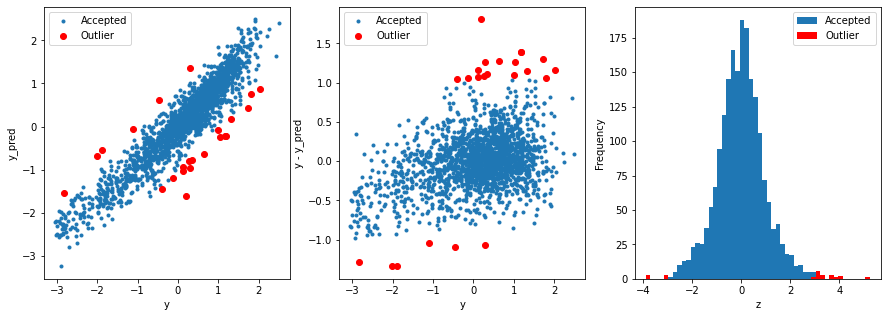

In [13]:
# get training data
from sklearn.linear_model import Ridge
X_train, X_valid,y_train,y_valid = get_training_data()
test=get_test_data()

# find and remove outliers using a Ridge model
outliers = find_outliers(Ridge(), X_train, y_train)

# permanently remove these outliers from the data
#df_train = data_all[data_all["oringin"]=="train"]
#df_train["label"]=data_train.target1
#df_train=df_train.drop(outliers)
X_outliers=X_train.loc[outliers]
y_outliers=y_train.loc[outliers]
X_t=X_train.drop(outliers)
y_t=y_train.drop(outliers)

In [14]:
def get_trainning_data_omitoutliers():
    y1=y_t.copy()
    X1=X_t.copy()
    return X1,y1

In [15]:
from sklearn.preprocessing import StandardScaler
def train_model(model, param_grid=[], X=[], y=[], 
                splits=5, repeats=5):

    # get unmodified training data, unless data to use already specified
    if len(y)==0:
        X,y = get_trainning_data_omitoutliers()
        #poly_trans=PolynomialFeatures(degree=2)
        #X=poly_trans.fit_transform(X)
        #X=MinMaxScaler().fit_transform(X)
    
    # create cross-validation method
    rkfold = RepeatedKFold(n_splits=splits, n_repeats=repeats)
    
    # perform a grid search if param_grid given
    if len(param_grid)>0:
        # setup grid search parameters
        gsearch = GridSearchCV(model, param_grid, cv=rkfold,
                               scoring="neg_mean_squared_error",
                               verbose=1, return_train_score=True)

        # search the grid
        gsearch.fit(X,y)

        # extract best model from the grid
        model = gsearch.best_estimator_        
        best_idx = gsearch.best_index_
        # get cv-scores for best model
        grid_results = pd.DataFrame(gsearch.cv_results_)       
        cv_mean = abs(grid_results.loc[best_idx,'mean_test_score'])
        cv_std = grid_results.loc[best_idx,'std_test_score']

    # no grid search, just cross-val score for given model    
    else:
        grid_results = []
        cv_results = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=rkfold)
        cv_mean = abs(np.mean(cv_results))
        cv_std = np.std(cv_results)
    
    # combine mean and std cv-score in to a pandas series
    cv_score = pd.Series({'mean':cv_mean,'std':cv_std})

    # predict y using the fitted model
    y_pred = model.predict(X)
    
    # print stats on model performance         
    print('----------------------')
    print(model)
    print('----------------------')
    print('score=',model.score(X,y))
    print('rmse=',rmse(y, y_pred))
    print('mse=',mse(y, y_pred))
    print('cross_val: mean=',cv_mean,', std=',cv_std)
    # residual plots
    y_pred = pd.Series(y_pred,index=y.index)
    resid = y - y_pred
    mean_resid = resid.mean()
    std_resid = resid.std()
    z = (resid - mean_resid)/std_resid    
    n_outliers = sum(abs(z)>3)
    
    plt.figure(figsize=(15,5))
    ax_131 = plt.subplot(1,3,1)
    plt.plot(y,y_pred,'.')
    plt.xlabel('y')
    plt.ylabel('y_pred');
    plt.title('corr = {:.3f}'.format(np.corrcoef(y,y_pred)[0][1]))
    ax_132=plt.subplot(1,3,2)
    plt.plot(y,y-y_pred,'.')
    plt.xlabel('y')
    plt.ylabel('y - y_pred');
    plt.title('std resid = {:.3f}'.format(std_resid))
    
    ax_133=plt.subplot(1,3,3)
    z.plot.hist(bins=50,ax=ax_133)
    plt.xlabel('z')
    plt.title('{:.0f} samples with z>3'.format(n_outliers))

    return model, cv_score, grid_results

In [16]:
# places to store optimal models and scores
opt_models = dict()
score_models = pd.DataFrame(columns=['mean','std'])

# no. k-fold splits
splits=5
# no. k-fold iterations
repeats=5

Fitting 25 folds for each of 23 candidates, totalling 575 fits
----------------------
Ridge(alpha=0.25)
----------------------
score= 0.8963563381522175
rmse= 0.3189964921433827
mse= 0.10175876199978322
cross_val: mean= 0.10655418298325582 , std= 0.007134751303842334


Text(0, 0.5, 'score')

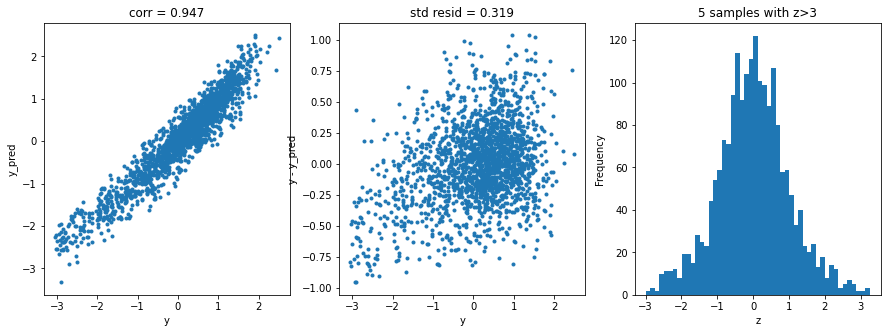

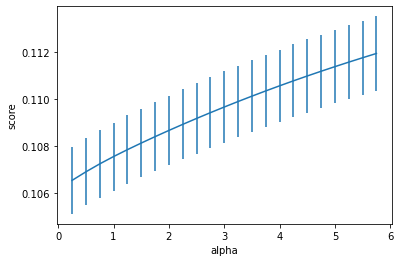

In [17]:
model = 'Ridge'

opt_models[model] = Ridge()
alph_range = np.arange(0.25,6,0.25)
param_grid = {'alpha': alph_range}

opt_models[model],cv_score,grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=repeats)

cv_score.name = model
score_models = score_models.append(cv_score)

plt.figure()
plt.errorbar(alph_range, abs(grid_results['mean_test_score']),
             abs(grid_results['std_test_score'])/np.sqrt(splits*repeats))
plt.xlabel('alpha')
plt.ylabel('score')

Fitting 25 folds for each of 23 candidates, totalling 575 fits
----------------------
Lasso(alpha=0.0001)
----------------------
score= 0.8965376189884907
rmse= 0.3187173951953969
mse= 0.10158077800013889
cross_val: mean= 0.10562754276464864 , std= 0.006421296391577616


Text(0, 0.5, 'score')

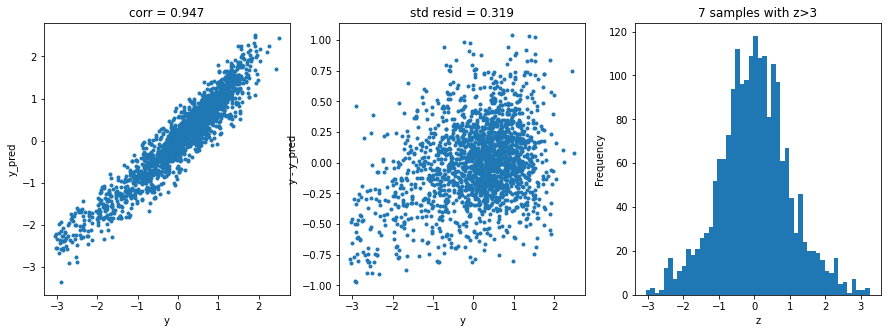

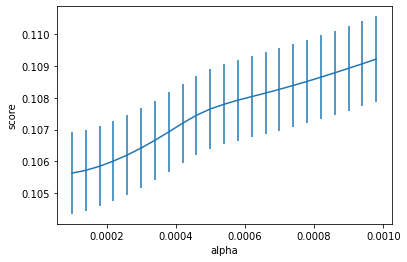

In [18]:
model = 'Lasso' #套索算法

opt_models[model] = Lasso()
alph_range = np.arange(1e-4,1e-3,4e-5)
param_grid = {'alpha': alph_range}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=repeats)

cv_score.name = model
score_models = score_models.append(cv_score)

plt.figure()
plt.errorbar(alph_range, abs(grid_results['mean_test_score']),abs(grid_results['std_test_score'])/np.sqrt(splits*repeats))
plt.xlabel('alpha')
plt.ylabel('score')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
----------------------
ElasticNet(alpha=0.0001, l1_ratio=0.9, max_iter=100000)
----------------------
score= 0.8965268088444412
rmse= 0.3187340451648231
mse= 0.10159139154713155
cross_val: mean= 0.10567691756091366 , std= 0.0068876986716570505


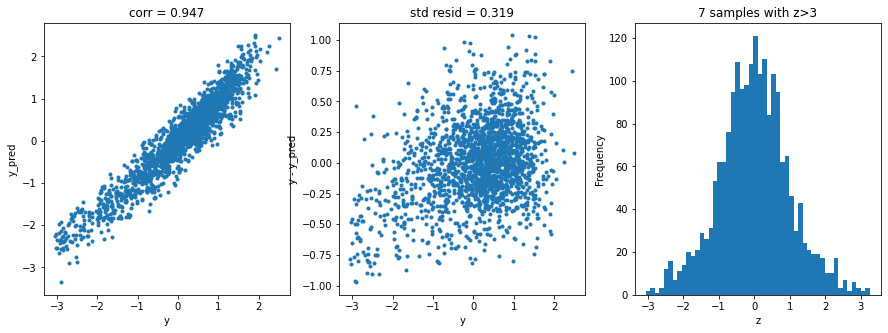

In [19]:
model ='ElasticNet'  #弹性网络
opt_models[model] = ElasticNet()

param_grid = {'alpha': np.arange(1e-4,1e-3,1e-4),
              'l1_ratio': np.arange(0.1,1.0,0.1),
              'max_iter':[100000]}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=1)

cv_score.name = model
score_models = score_models.append(cv_score)

Fitting 25 folds for each of 9 candidates, totalling 225 fits
----------------------
LinearSVR(C=0.30000000000000004)
----------------------
score= -1.8627812610593697
rmse= 1.6765195259152386
mse= 2.810717720775053
cross_val: mean= 1.4427888641397308 , std= 1.473598166797124


Text(0, 0.5, 'score')

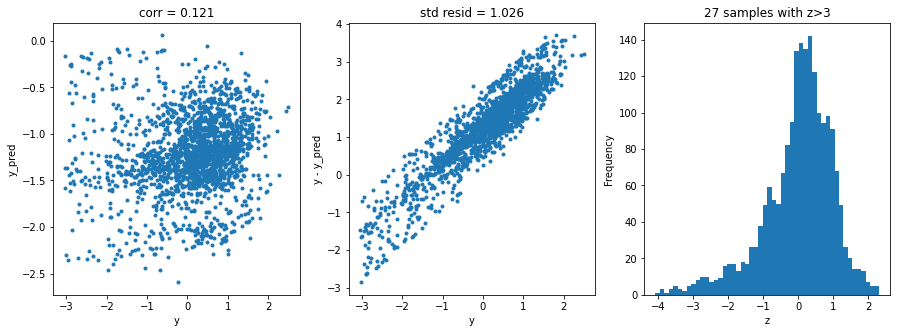

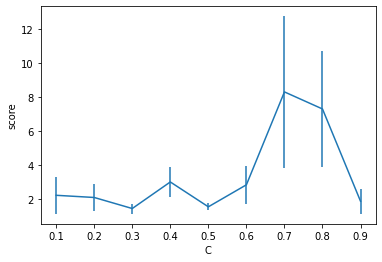

In [20]:
model='LinearSVR'
opt_models[model] = LinearSVR()

crange = np.arange(0.1,1.0,0.1)
param_grid = {'C':crange,
             'max_iter':[1000]}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=repeats)


cv_score.name = model
score_models = score_models.append(cv_score)

plt.figure()
plt.errorbar(crange, abs(grid_results['mean_test_score']),abs(grid_results['std_test_score'])/np.sqrt(splits*repeats))
plt.xlabel('C')
plt.ylabel('score')


Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------------------
KNeighborsRegressor(n_neighbors=10)
----------------------
score= 0.7188007679386812
rmse= 0.5254381453364181
mse= 0.27608524457457456
cross_val: mean= 0.342148292725188 , std= 0.03090113169431735


Text(0, 0.5, 'score')

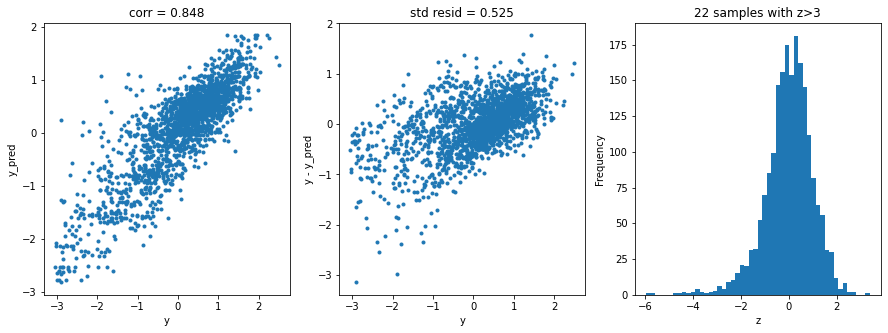

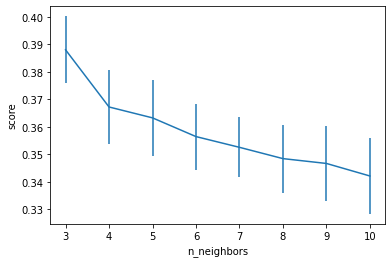

In [21]:
model = 'KNeighbors'
opt_models[model] = KNeighborsRegressor()

param_grid = {'n_neighbors':np.arange(3,11,1)}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=1)

cv_score.name = model
score_models = score_models.append(cv_score)

plt.figure()
plt.errorbar(np.arange(3,11,1), abs(grid_results['mean_test_score']),abs(grid_results['std_test_score'])/np.sqrt(splits*1))
plt.xlabel('n_neighbors')
plt.ylabel('score')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
----------------------
GradientBoostingRegressor(min_samples_split=7, n_estimators=250)
----------------------
score= 0.9675906094630619
rmse= 0.17838156305129588
mse= 0.031819982036623486
cross_val: mean= 0.09589548942760923 , std= 0.007688250415593408


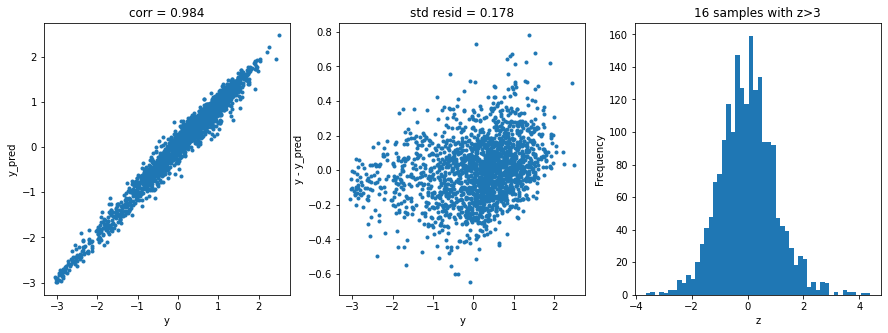

In [22]:
model = 'GradientBoosting'
opt_models[model] = GradientBoostingRegressor()

param_grid = {'n_estimators':[150,250,350],
              'max_depth':[1,2,3],
              'min_samples_split':[5,6,7]}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=1)

cv_score.name = model
score_models = score_models.append(cv_score)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
----------------------
XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
             importance_type='gain', interaction_constraints='',
             learning_rate=0.300000012, max_delta_step=0, max_depth=2,
             min_child_weight=1, missing=nan, monotone_constraints='()',
             n_estimators=200, n_jobs=8, num_parallel_tree=1, random_state=0,
             reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
             tree_method='exact', validate_parameters=1, verbosity=None)
----------------------
score= 0.9614714579396122
rmse= 0.19449382646347452
mse= 0.03782784853240417
cross_val: mean= 0.1038154904385991 , std= 0.009307794769379693


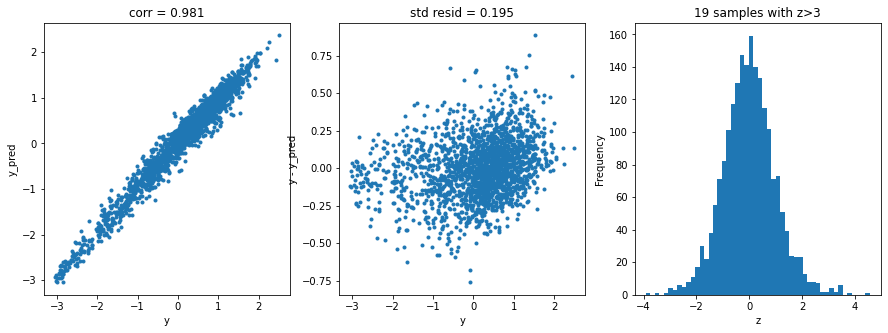

In [23]:
model = 'XGB'
opt_models[model] = XGBRegressor()

param_grid = {'n_estimators':[100,200,300,400,500],
              'max_depth':[1,2,3],
             }

opt_models[model], cv_score,grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=splits, repeats=1)

cv_score.name = model
score_models = score_models.append(cv_score)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
----------------------
RandomForestRegressor(max_features=12, n_estimators=200)
----------------------
score= 0.9854992143526238
rmse= 0.11931919079906184
mse= 0.014237069292942944
cross_val: mean= 0.10333319225999978 , std= 0.0053454712113989115


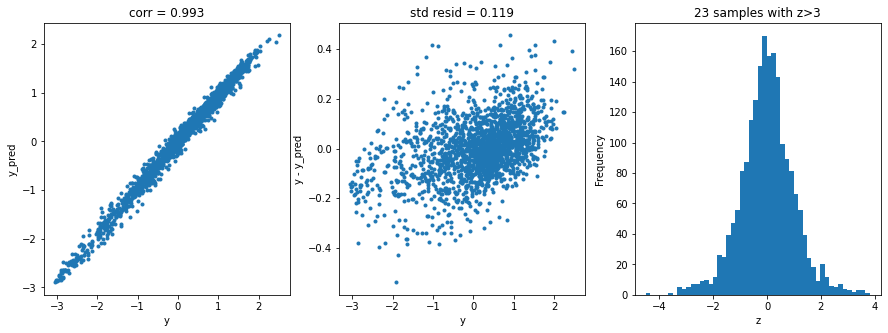

In [24]:
model = 'RandomForest'
opt_models[model] = RandomForestRegressor()

param_grid = {'n_estimators':[100,150,200],
              'max_features':[8,12,16,20,24],
              'min_samples_split':[2,4,6]}

opt_models[model], cv_score, grid_results = train_model(opt_models[model], param_grid=param_grid, 
                                              splits=5, repeats=1)

cv_score.name = model
score_models = score_models.append(cv_score)

In [25]:
def model_predict(test_data,test_y=[],stack=False):
    #poly_trans=PolynomialFeatures(degree=2)
    #test_data1=poly_trans.fit_transform(test_data)
    #test_data=MinMaxScaler().fit_transform(test_data)
    i=0
    y_predict_total=np.zeros((test_data.shape[0],))
    for model in opt_models.keys():
        if model!="LinearSVR" and model!="KNeighbors":
            y_predict=opt_models[model].predict(test_data)
            y_predict_total+=y_predict
            i+=1
        if len(test_y)>0:
            print("{}_mse:".format(model),mean_squared_error(y_predict,test_y))
    y_predict_mean=np.round(y_predict_total/i,3)
    if len(test_y)>0:
        print("mean_mse:",mean_squared_error(y_predict_mean,test_y))
    else:
        y_predict_mean=pd.Series(y_predict_mean)
        return y_predict_mean

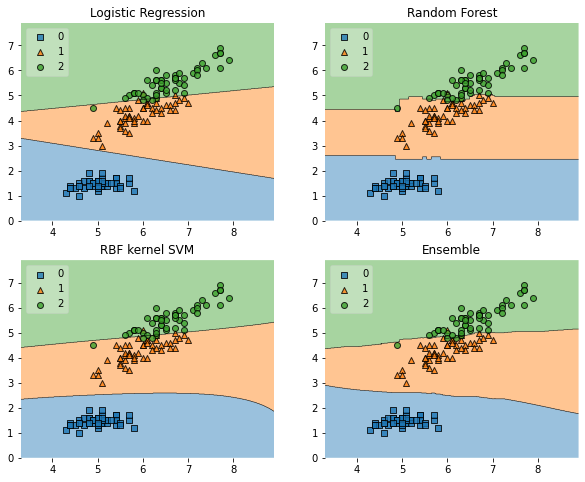

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

##主要使用pip install mlxtend安装mlxtend
from mlxtend.classifier import EnsembleVoteClassifier
from mlxtend.data import iris_data
from mlxtend.plotting import plot_decision_regions
%matplotlib inline

# Initializing Classifiers
clf1 = LogisticRegression(random_state=0)
clf2 = RandomForestClassifier(random_state=0)
clf3 = SVC(random_state=0, probability=True)
eclf = EnsembleVoteClassifier(clfs=[clf1, clf2, clf3], weights=[2, 1, 1], voting='soft')

# Loading some example data
X, y = iris_data()
X = X[:,[0, 2]]

# Plotting Decision Regions
gs = gridspec.GridSpec(2, 2)
fig = plt.figure(figsize=(10, 8))

for clf, lab, grd in zip([clf1, clf2, clf3, eclf],
                         ['Logistic Regression', 'Random Forest', 'RBF kernel SVM', 'Ensemble'],
                         itertools.product([0, 1], repeat=2)):
    clf.fit(X, y)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=X, y=y, clf=clf, legend=2)
    plt.title(lab)
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from scipy import sparse
import xgboost
import lightgbm

from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor,ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def stacking_reg(clf,train_x,train_y,test_x,clf_name,kf,label_split=None):
    train=np.zeros((train_x.shape[0],1))
    test=np.zeros((test_x.shape[0],1))
    test_pre=np.empty((folds,test_x.shape[0],1))
    cv_scores=[]
    for i,(train_index,test_index) in enumerate(kf.split(train_x,label_split)):       
        tr_x=train_x[train_index]
        tr_y=train_y[train_index]
        te_x=train_x[test_index]
        te_y = train_y[test_index]
        if clf_name in ["rf","ada","gb","et","lr","lsvc","knn"]:
            clf.fit(tr_x,tr_y)
            pre=clf.predict(te_x).reshape(-1,1)
            train[test_index]=pre
            test_pre[i,:]=clf.predict(test_x).reshape(-1,1)
            cv_scores.append(mean_squared_error(te_y, pre))
        elif clf_name in ["xgb"]:
            train_matrix = clf.DMatrix(tr_x, label=tr_y, missing=-1)
            test_matrix = clf.DMatrix(te_x, label=te_y, missing=-1)
            z = clf.DMatrix(test_x, label=te_y, missing=-1)
            params = {'booster': 'gbtree',
                      'eval_metric': 'rmse',
                      'gamma': 1,
                      'min_child_weight': 1.5,
                      'max_depth': 5,
                      'lambda': 10,
                      'subsample': 0.7,
                      'colsample_bytree': 0.7,
                      'colsample_bylevel': 0.7,
                      'eta': 0.03,
                      'tree_method': 'exact',
                      'seed': 2017,
                      'nthread': 12
                      }
            num_round = 10000
            early_stopping_rounds = 100
            watchlist = [(train_matrix, 'train'),
                         (test_matrix, 'eval')
                         ]
            if test_matrix:
                model = clf.train(params, train_matrix, num_boost_round=num_round,evals=watchlist,
                                  early_stopping_rounds=early_stopping_rounds
                                  )
                pre= model.predict(test_matrix,ntree_limit=model.best_ntree_limit).reshape(-1,1)
                train[test_index]=pre
                test_pre[i, :]= model.predict(z, ntree_limit=model.best_ntree_limit).reshape(-1,1)
                cv_scores.append(mean_squared_error(te_y, pre))
        elif clf_name in ["lgb"]:
            train_matrix = clf.Dataset(tr_x, label=tr_y)
            test_matrix = clf.Dataset(te_x, label=te_y)
            #z = clf.Dataset(test_x, label=te_y)
            #z=test_x
            params = {
                      'boosting_type': 'gbdt',
                      'objective': 'regression_l2',
                      'metric': 'mse',
                      'min_child_weight': 1.5,
                      'num_leaves': 2**5,
                      'lambda_l2': 10,
                      'subsample': 0.7,
                      'colsample_bytree': 0.7,
                      'colsample_bylevel': 0.7,
                      'learning_rate': 0.03,
                      'tree_method': 'exact',
                      'seed': 2017,
                      'nthread': 12,
                      'silent': True,
                      }
            num_round = 10000
            early_stopping_rounds = 100
            if test_matrix:
                model = clf.train(params, train_matrix,num_round,valid_sets=test_matrix,
                                  early_stopping_rounds=early_stopping_rounds
                                  )
                pre= model.predict(te_x,num_iteration=model.best_iteration).reshape(-1,1)
                train[test_index]=pre
                test_pre[i, :]= model.predict(test_x, num_iteration=model.best_iteration).reshape(-1,1)
                cv_scores.append(mean_squared_error(te_y, pre))
        else:
            raise IOError("Please add new clf.")
        print("%s now score is:"%clf_name,cv_scores)
    test[:]=test_pre.mean(axis=0)
    print("%s_score_list:"%clf_name,cv_scores)
    print("%s_score_mean:"%clf_name,np.mean(cv_scores))
    return train.reshape(-1,1),test.reshape(-1,1)

In [28]:
def rf_reg(x_train, y_train, x_valid, kf, label_split=None):
    randomforest = RandomForestRegressor(n_estimators=600, max_depth=20, n_jobs=-1, random_state=2017, max_features="auto",verbose=1)
    rf_train, rf_test = stacking_reg(randomforest, x_train, y_train, x_valid, "rf", kf, label_split=label_split)
    return rf_train, rf_test,"rf_reg"

def ada_reg(x_train, y_train, x_valid, kf, label_split=None):
    adaboost = AdaBoostRegressor(n_estimators=30, random_state=2017, learning_rate=0.01)
    ada_train, ada_test = stacking_reg(adaboost, x_train, y_train, x_valid, "ada", kf, label_split=label_split)
    return ada_train, ada_test,"ada_reg"

def gb_reg(x_train, y_train, x_valid, kf, label_split=None):
    gbdt = GradientBoostingRegressor(learning_rate=0.04, n_estimators=100, subsample=0.8, random_state=2017,max_depth=5,verbose=1)
    gbdt_train, gbdt_test = stacking_reg(gbdt, x_train, y_train, x_valid, "gb", kf, label_split=label_split)
    return gbdt_train, gbdt_test,"gb_reg"

def et_reg(x_train, y_train, x_valid, kf, label_split=None):
    extratree = ExtraTreesRegressor(n_estimators=600, max_depth=35, max_features="auto", n_jobs=-1, random_state=2017,verbose=1)
    et_train, et_test = stacking_reg(extratree, x_train, y_train, x_valid, "et", kf, label_split=label_split)
    return et_train, et_test,"et_reg"

def lr_reg(x_train, y_train, x_valid, kf, label_split=None):
    lr_reg=LinearRegression(n_jobs=-1)
    lr_train, lr_test = stacking_reg(lr_reg, x_train, y_train, x_valid, "lr", kf, label_split=label_split)
    return lr_train, lr_test, "lr_reg"

def xgb_reg(x_train, y_train, x_valid, kf, label_split=None):
    xgb_train, xgb_test = stacking_reg(xgboost, x_train, y_train, x_valid, "xgb", kf, label_split=label_split)
    return xgb_train, xgb_test,"xgb_reg"

def lgb_reg(x_train, y_train, x_valid, kf, label_split=None):
    lgb_train, lgb_test = stacking_reg(lightgbm, x_train, y_train, x_valid, "lgb", kf, label_split=label_split)
    return lgb_train, lgb_test,"lgb_reg"

In [29]:
def stacking_pred(x_train, y_train, x_valid, kf, clf_list, label_split=None, clf_fin="lgb", if_concat_origin=True):
    for k, clf_list in enumerate(clf_list):
        clf_list = [clf_list]
        column_list = []
        train_data_list=[]
        test_data_list=[]
        for clf in clf_list:
            train_data,test_data,clf_name=clf(x_train, y_train, x_valid, kf, label_split=label_split)
            train_data_list.append(train_data)
            test_data_list.append(test_data)
            column_list.append("clf_%s" % (clf_name))
    train = np.concatenate(train_data_list, axis=1)
    test = np.concatenate(test_data_list, axis=1)
    
    if if_concat_origin:
        train = np.concatenate([x_train, train], axis=1)
        test = np.concatenate([x_valid, test], axis=1)
    print(x_train.shape)
    print(train.shape)
    print(clf_name)
    print(clf_name in ["lgb"])
    if clf_fin in ["rf","ada","gb","et","lr","lsvc","knn"]:
        if clf_fin in ["rf"]:
            clf = RandomForestRegressor(n_estimators=600, max_depth=20, n_jobs=-1, random_state=2017, max_features="auto",verbose=1)
        elif clf_fin in ["ada"]:
            clf = AdaBoostRegressor(n_estimators=30, random_state=2017, learning_rate=0.01)
        elif clf_fin in ["gb"]:
            clf = GradientBoostingRegressor(learning_rate=0.04, n_estimators=100, subsample=0.8, random_state=2017,max_depth=5,verbose=1)
        elif clf_fin in ["et"]:
            clf = ExtraTreesRegressor(n_estimators=600, max_depth=35, max_features="auto", n_jobs=-1, random_state=2017,verbose=1)
        elif clf_fin in ["lr"]:
            clf = LinearRegression(n_jobs=-1)
        clf.fit(train, y_train)
        pre = clf.predict(test).reshape(-1,1)
        return pred
    elif clf_fin in ["xgb"]:
        clf = xgboost
        train_matrix = clf.DMatrix(train, label=y_train, missing=-1)
        test_matrix = clf.DMatrix(train, label=y_train, missing=-1)
        params = {'booster': 'gbtree',
                  'eval_metric': 'rmse',
                  'gamma': 1,
                  'min_child_weight': 1.5,
                  'max_depth': 5,
                  'lambda': 10,
                  'subsample': 0.7,
                  'colsample_bytree': 0.7,
                  'colsample_bylevel': 0.7,
                  'eta': 0.03,
                  'tree_method': 'exact',
                  'seed': 2017,
                  'nthread': 12
                  }
        num_round = 10000
        early_stopping_rounds = 100
        watchlist = [(train_matrix, 'train'),
                     (test_matrix, 'eval')
                     ]
        model = clf.train(params, train_matrix, num_boost_round=num_round,evals=watchlist,
                          early_stopping_rounds=early_stopping_rounds
                          )
        pre = model.predict(test,ntree_limit=model.best_ntree_limit).reshape(-1,1)
        return pre
    elif clf_fin in ["lgb"]:
        print(clf_name)
        clf = lightgbm
        train_matrix = clf.Dataset(train, label=y_train)
        test_matrix = clf.Dataset(train, label=y_train)
        params = {
                  'boosting_type': 'gbdt',
                  'objective': 'regression_l2',
                  'metric': 'mse',
                  'min_child_weight': 1.5,
                  'num_leaves': 2**5,
                  'lambda_l2': 10,
                  'subsample': 0.7,
                  'colsample_bytree': 0.7,
                  'colsample_bylevel': 0.7,
                  'learning_rate': 0.03,
                  'tree_method': 'exact',
                  'seed': 2017,
                  'nthread': 12,
                  'silent': True,
                  }
        num_round = 10000
        early_stopping_rounds = 100
        model = clf.train(params, train_matrix,num_round,valid_sets=test_matrix,
                          early_stopping_rounds=early_stopping_rounds
                          )
        print('pred')
        pre = model.predict(test,num_iteration=model.best_iteration).reshape(-1,1)
        print(pre)
        return pre

In [30]:
# #load_dataset
with open("./zhengqi_train.txt")  as fr:
    data_train=pd.read_table(fr,sep="\t")
with open("./zhengqi_test.txt") as fr_test:
    data_test=pd.read_table(fr_test,sep="\t")

In [31]:
from sklearn.model_selection import StratifiedKFold, KFold

folds = 5
seed = 1
kf = KFold(n_splits=5, shuffle=True, random_state=0)

In [32]:
x_train = data_train[data_test.columns].values
x_valid = data_test[data_test.columns].values
y_train = data_train['target'].values

In [33]:
clf_list = [lr_reg, lgb_reg]
#clf_list = [lr_reg, rf_reg]

##很容易过拟合
pred = stacking_pred(x_train, y_train, x_valid, kf, clf_list, label_split=None, clf_fin="lgb", if_concat_origin=True)

lr now score is: [0.11573216950871242]
lr now score is: [0.11573216950871242, 0.09417486426618928]
lr now score is: [0.11573216950871242, 0.09417486426618928, 0.10805046561851064]
lr now score is: [0.11573216950871242, 0.09417486426618928, 0.10805046561851064, 0.12420887065601556]
lr now score is: [0.11573216950871242, 0.09417486426618928, 0.10805046561851064, 0.12420887065601556, 0.11940113841914012]
lr_score_list: [0.11573216950871242, 0.09417486426618928, 0.10805046561851064, 0.12420887065601556, 0.11940113841914012]
lr_score_mean: 0.1123135016937136
[1]	valid_0's l2: 0.99242
Training until validation scores don't improve for 100 rounds.
[2]	valid_0's l2: 0.947914
[3]	valid_0's l2: 0.905974
[4]	valid_0's l2: 0.866148
[5]	valid_0's l2: 0.8284
[6]	valid_0's l2: 0.793559
[7]	valid_0's l2: 0.760142
[8]	valid_0's l2: 0.727888
[9]	valid_0's l2: 0.697803
[10]	valid_0's l2: 0.669207
[11]	valid_0's l2: 0.642964
[12]	valid_0's l2: 0.617145
[13]	valid_0's l2: 0.593609
[14]	valid_0's l2: 0.5701

[326]	valid_0's l2: 0.114534
[327]	valid_0's l2: 0.114513
[328]	valid_0's l2: 0.114519
[329]	valid_0's l2: 0.11445
[330]	valid_0's l2: 0.114427
[331]	valid_0's l2: 0.114371
[332]	valid_0's l2: 0.11435
[333]	valid_0's l2: 0.114349
[334]	valid_0's l2: 0.114215
[335]	valid_0's l2: 0.114209
[336]	valid_0's l2: 0.114182
[337]	valid_0's l2: 0.114146
[338]	valid_0's l2: 0.114125
[339]	valid_0's l2: 0.114148
[340]	valid_0's l2: 0.11412
[341]	valid_0's l2: 0.114085
[342]	valid_0's l2: 0.114068
[343]	valid_0's l2: 0.114021
[344]	valid_0's l2: 0.114036
[345]	valid_0's l2: 0.113947
[346]	valid_0's l2: 0.113893
[347]	valid_0's l2: 0.113887
[348]	valid_0's l2: 0.113863
[349]	valid_0's l2: 0.113805
[350]	valid_0's l2: 0.11377
[351]	valid_0's l2: 0.113751
[352]	valid_0's l2: 0.113756
[353]	valid_0's l2: 0.113734
[354]	valid_0's l2: 0.113673
[355]	valid_0's l2: 0.113681
[356]	valid_0's l2: 0.113622
[357]	valid_0's l2: 0.113614
[358]	valid_0's l2: 0.113583
[359]	valid_0's l2: 0.113568
[360]	valid_0's l2

[676]	valid_0's l2: 0.110496
[677]	valid_0's l2: 0.110502
[678]	valid_0's l2: 0.110484
[679]	valid_0's l2: 0.110457
[680]	valid_0's l2: 0.110449
[681]	valid_0's l2: 0.110439
[682]	valid_0's l2: 0.110423
[683]	valid_0's l2: 0.110396
[684]	valid_0's l2: 0.110411
[685]	valid_0's l2: 0.110401
[686]	valid_0's l2: 0.1104
[687]	valid_0's l2: 0.11038
[688]	valid_0's l2: 0.110375
[689]	valid_0's l2: 0.110348
[690]	valid_0's l2: 0.110345
[691]	valid_0's l2: 0.110319
[692]	valid_0's l2: 0.110306
[693]	valid_0's l2: 0.110288
[694]	valid_0's l2: 0.110263
[695]	valid_0's l2: 0.110263
[696]	valid_0's l2: 0.110238
[697]	valid_0's l2: 0.110233
[698]	valid_0's l2: 0.110233
[699]	valid_0's l2: 0.110232
[700]	valid_0's l2: 0.110234
[701]	valid_0's l2: 0.110239
[702]	valid_0's l2: 0.11024
[703]	valid_0's l2: 0.110228
[704]	valid_0's l2: 0.110208
[705]	valid_0's l2: 0.110194
[706]	valid_0's l2: 0.110183
[707]	valid_0's l2: 0.110156
[708]	valid_0's l2: 0.110142
[709]	valid_0's l2: 0.110125
[710]	valid_0's l2

[975]	valid_0's l2: 0.108761
[976]	valid_0's l2: 0.108768
[977]	valid_0's l2: 0.108751
[978]	valid_0's l2: 0.108748
[979]	valid_0's l2: 0.108746
[980]	valid_0's l2: 0.108757
[981]	valid_0's l2: 0.108746
[982]	valid_0's l2: 0.108755
[983]	valid_0's l2: 0.108748
[984]	valid_0's l2: 0.108748
[985]	valid_0's l2: 0.108749
[986]	valid_0's l2: 0.108745
[987]	valid_0's l2: 0.108743
[988]	valid_0's l2: 0.108742
[989]	valid_0's l2: 0.108717
[990]	valid_0's l2: 0.108723
[991]	valid_0's l2: 0.108726
[992]	valid_0's l2: 0.10873
[993]	valid_0's l2: 0.108733
[994]	valid_0's l2: 0.108731
[995]	valid_0's l2: 0.108722
[996]	valid_0's l2: 0.108723
[997]	valid_0's l2: 0.10872
[998]	valid_0's l2: 0.10872
[999]	valid_0's l2: 0.108709
[1000]	valid_0's l2: 0.108697
[1001]	valid_0's l2: 0.108699
[1002]	valid_0's l2: 0.1087
[1003]	valid_0's l2: 0.108699
[1004]	valid_0's l2: 0.108695
[1005]	valid_0's l2: 0.10871
[1006]	valid_0's l2: 0.108707
[1007]	valid_0's l2: 0.108707
[1008]	valid_0's l2: 0.108711
[1009]	vali

[1277]	valid_0's l2: 0.108376
[1278]	valid_0's l2: 0.108374
[1279]	valid_0's l2: 0.108368
[1280]	valid_0's l2: 0.10836
[1281]	valid_0's l2: 0.108368
[1282]	valid_0's l2: 0.108372
[1283]	valid_0's l2: 0.108366
[1284]	valid_0's l2: 0.108361
[1285]	valid_0's l2: 0.108364
[1286]	valid_0's l2: 0.108367
[1287]	valid_0's l2: 0.108369
[1288]	valid_0's l2: 0.108378
[1289]	valid_0's l2: 0.108369
[1290]	valid_0's l2: 0.108372
[1291]	valid_0's l2: 0.108374
[1292]	valid_0's l2: 0.108373
[1293]	valid_0's l2: 0.108369
[1294]	valid_0's l2: 0.10837
[1295]	valid_0's l2: 0.108375
[1296]	valid_0's l2: 0.108368
[1297]	valid_0's l2: 0.10837
[1298]	valid_0's l2: 0.108376
[1299]	valid_0's l2: 0.10837
[1300]	valid_0's l2: 0.108374
[1301]	valid_0's l2: 0.108373
[1302]	valid_0's l2: 0.108369
[1303]	valid_0's l2: 0.108367
[1304]	valid_0's l2: 0.108374
[1305]	valid_0's l2: 0.108368
[1306]	valid_0's l2: 0.108364
[1307]	valid_0's l2: 0.108366
[1308]	valid_0's l2: 0.108358
[1309]	valid_0's l2: 0.108353
[1310]	valid_0

...

[8672]	valid_0's l2: 1.39213e-09
[8673]	valid_0's l2: 1.39064e-09
[8674]	valid_0's l2: 1.38915e-09
[8675]	valid_0's l2: 1.38668e-09
[8676]	valid_0's l2: 1.38433e-09
[8677]	valid_0's l2: 1.38275e-09
[8678]	valid_0's l2: 1.38135e-09
[8679]	valid_0's l2: 1.37965e-09
[8680]	valid_0's l2: 1.37745e-09
[8681]	valid_0's l2: 1.37586e-09
[8682]	valid_0's l2: 1.37429e-09
[8683]	valid_0's l2: 1.37285e-09
[8684]	valid_0's l2: 1.37066e-09
[8685]	valid_0's l2: 1.36926e-09
[8686]	valid_0's l2: 1.36724e-09
[8687]	valid_0's l2: 1.36589e-09
[8688]	valid_0's l2: 1.36307e-09
[8689]	valid_0's l2: 1.36144e-09
[8690]	valid_0's l2: 1.35992e-09
[8691]	valid_0's l2: 1.35832e-09
[8692]	valid_0's l2: 1.35622e-09
[8693]	valid_0's l2: 1.35426e-09
[8694]	valid_0's l2: 1.35191e-09
[8695]	valid_0's l2: 1.35056e-09
[8696]	valid_0's l2: 1.34937e-09
[8697]	valid_0's l2: 1.3474e-09
[8698]	valid_0's l2: 1.34598e-09
[8699]	valid_0's l2: 1.3442e-09
[8700]	valid_0's l2: 1.34289e-09
[8701]	valid_0's l2: 1.34123e-09
[8702]	valid

[8949]	valid_0's l2: 9.66856e-10
[8950]	valid_0's l2: 9.65402e-10
[8951]	valid_0's l2: 9.64396e-10
[8952]	valid_0's l2: 9.62537e-10
[8953]	valid_0's l2: 9.61645e-10
[8954]	valid_0's l2: 9.60181e-10
[8955]	valid_0's l2: 9.59252e-10
[8956]	valid_0's l2: 9.58192e-10
[8957]	valid_0's l2: 9.56609e-10
[8958]	valid_0's l2: 9.54751e-10
[8959]	valid_0's l2: 9.53906e-10
[8960]	valid_0's l2: 9.52426e-10
[8961]	valid_0's l2: 9.51613e-10
[8962]	valid_0's l2: 9.50104e-10
[8963]	valid_0's l2: 9.4891e-10
[8964]	valid_0's l2: 9.48126e-10
[8965]	valid_0's l2: 9.4631e-10
[8966]	valid_0's l2: 9.4536e-10
[8967]	valid_0's l2: 9.43602e-10
[8968]	valid_0's l2: 9.41956e-10
[8969]	valid_0's l2: 9.41162e-10
[8970]	valid_0's l2: 9.40215e-10
[8971]	valid_0's l2: 9.38629e-10
[8972]	valid_0's l2: 9.37788e-10
[8973]	valid_0's l2: 9.37015e-10
[8974]	valid_0's l2: 9.35692e-10
[8975]	valid_0's l2: 9.34787e-10
[8976]	valid_0's l2: 9.33341e-10
[8977]	valid_0's l2: 9.32249e-10
[8978]	valid_0's l2: 9.31489e-10
[8979]	valid_

[9222]	valid_0's l2: 6.8262e-10
[9223]	valid_0's l2: 6.81567e-10
[9224]	valid_0's l2: 6.80507e-10
[9225]	valid_0's l2: 6.79886e-10
[9226]	valid_0's l2: 6.79233e-10
[9227]	valid_0's l2: 6.78533e-10
[9228]	valid_0's l2: 6.77922e-10
[9229]	valid_0's l2: 6.77045e-10
[9230]	valid_0's l2: 6.76341e-10
[9231]	valid_0's l2: 6.7541e-10
[9232]	valid_0's l2: 6.74851e-10
[9233]	valid_0's l2: 6.73533e-10
[9234]	valid_0's l2: 6.72852e-10
[9235]	valid_0's l2: 6.71882e-10
[9236]	valid_0's l2: 6.71232e-10
[9237]	valid_0's l2: 6.70604e-10
[9238]	valid_0's l2: 6.69961e-10
[9239]	valid_0's l2: 6.69297e-10
[9240]	valid_0's l2: 6.68576e-10
[9241]	valid_0's l2: 6.67517e-10
[9242]	valid_0's l2: 6.66277e-10
[9243]	valid_0's l2: 6.65638e-10
[9244]	valid_0's l2: 6.64971e-10
[9245]	valid_0's l2: 6.64366e-10
[9246]	valid_0's l2: 6.63671e-10
[9247]	valid_0's l2: 6.62963e-10
[9248]	valid_0's l2: 6.61935e-10
[9249]	valid_0's l2: 6.61284e-10
[9250]	valid_0's l2: 6.60641e-10
[9251]	valid_0's l2: 6.59949e-10
[9252]	valid

[9497]	valid_0's l2: 4.86898e-10
[9498]	valid_0's l2: 4.86111e-10
[9499]	valid_0's l2: 4.85659e-10
[9500]	valid_0's l2: 4.85229e-10
[9501]	valid_0's l2: 4.84396e-10
[9502]	valid_0's l2: 4.83537e-10
[9503]	valid_0's l2: 4.83062e-10
[9504]	valid_0's l2: 4.82544e-10
[9505]	valid_0's l2: 4.81722e-10
[9506]	valid_0's l2: 4.80909e-10
[9507]	valid_0's l2: 4.8051e-10
[9508]	valid_0's l2: 4.79761e-10
[9509]	valid_0's l2: 4.79373e-10
[9510]	valid_0's l2: 4.78606e-10
[9511]	valid_0's l2: 4.78089e-10
[9512]	valid_0's l2: 4.77628e-10
[9513]	valid_0's l2: 4.77172e-10
[9514]	valid_0's l2: 4.76399e-10
[9515]	valid_0's l2: 4.75659e-10
[9516]	valid_0's l2: 4.75181e-10
[9517]	valid_0's l2: 4.74013e-10
[9518]	valid_0's l2: 4.73504e-10
[9519]	valid_0's l2: 4.72739e-10
[9520]	valid_0's l2: 4.7197e-10
[9521]	valid_0's l2: 4.71231e-10
[9522]	valid_0's l2: 4.70797e-10
[9523]	valid_0's l2: 4.70294e-10
[9524]	valid_0's l2: 4.69899e-10
[9525]	valid_0's l2: 4.69086e-10
[9526]	valid_0's l2: 4.6871e-10
[9527]	valid_

[9775]	valid_0's l2: 3.44004e-10
[9776]	valid_0's l2: 3.43682e-10
[9777]	valid_0's l2: 3.43345e-10
[9778]	valid_0's l2: 3.43052e-10
[9779]	valid_0's l2: 3.42727e-10
[9780]	valid_0's l2: 3.42425e-10
[9781]	valid_0's l2: 3.42109e-10
[9782]	valid_0's l2: 3.41495e-10
[9783]	valid_0's l2: 3.4097e-10
[9784]	valid_0's l2: 3.40674e-10
[9785]	valid_0's l2: 3.40388e-10
[9786]	valid_0's l2: 3.39839e-10
[9787]	valid_0's l2: 3.39489e-10
[9788]	valid_0's l2: 3.39189e-10
[9789]	valid_0's l2: 3.38879e-10
[9790]	valid_0's l2: 3.38332e-10
[9791]	valid_0's l2: 3.38019e-10
[9792]	valid_0's l2: 3.37242e-10
[9793]	valid_0's l2: 3.36914e-10
[9794]	valid_0's l2: 3.36586e-10
[9795]	valid_0's l2: 3.36246e-10
[9796]	valid_0's l2: 3.35959e-10
[9797]	valid_0's l2: 3.35339e-10
[9798]	valid_0's l2: 3.34806e-10
[9799]	valid_0's l2: 3.3446e-10
[9800]	valid_0's l2: 3.33881e-10
[9801]	valid_0's l2: 3.33343e-10
[9802]	valid_0's l2: 3.33056e-10
[9803]	valid_0's l2: 3.32752e-10
[9804]	valid_0's l2: 3.32277e-10
[9805]	valid

In [34]:
pred

array([[ 0.43433247],
       [ 0.2806704 ],
       [ 0.08252265],
       ...,
       [-2.48209825],
       [-2.5028977 ],
       [-2.54543141]])